# Деревья решений

**Цель работы:** научиться применять модель дерева принятия решений для задач классификации и регрессии.

**Содержание работы:**
1. Классификация: обучение DecisionTreeClassifier, визуализация дерева и разделяющих областей.
2. Регрессия: обучение DecisionTreeRegressor, визуализация кусочно-линейной регрессии.

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, r2_score, mean_squared_error

## 2. Задача классификации

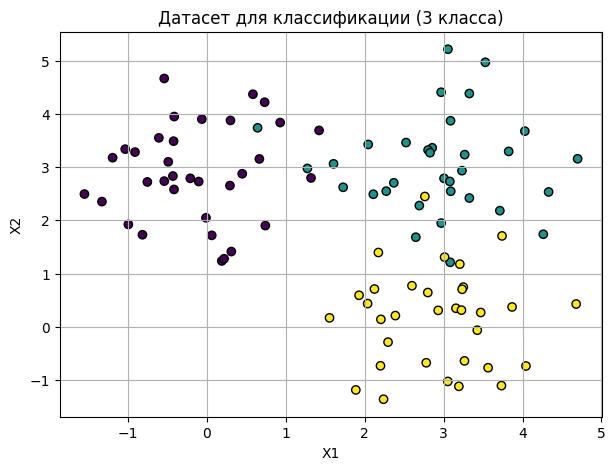

In [2]:
RANDOM_SEED = 42
X, y = make_blobs(n_samples=100, centers=[(0, 3), (3, 3), (3, 0)],
                  n_features=2, random_state=RANDOM_SEED, cluster_std=(0.9, 0.9, 0.9))

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title('Датасет для классификации (3 класса)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.show()

### Обучение DecisionTreeClassifier

In [3]:
depth = 4
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=RANDOM_SEED)
clf_tree.fit(X, y)
print(f'Дерево обучено (глубина = {depth}, критерий = entropy)')

Дерево обучено (глубина = 4, критерий = entropy)


### Визуализация дерева решений

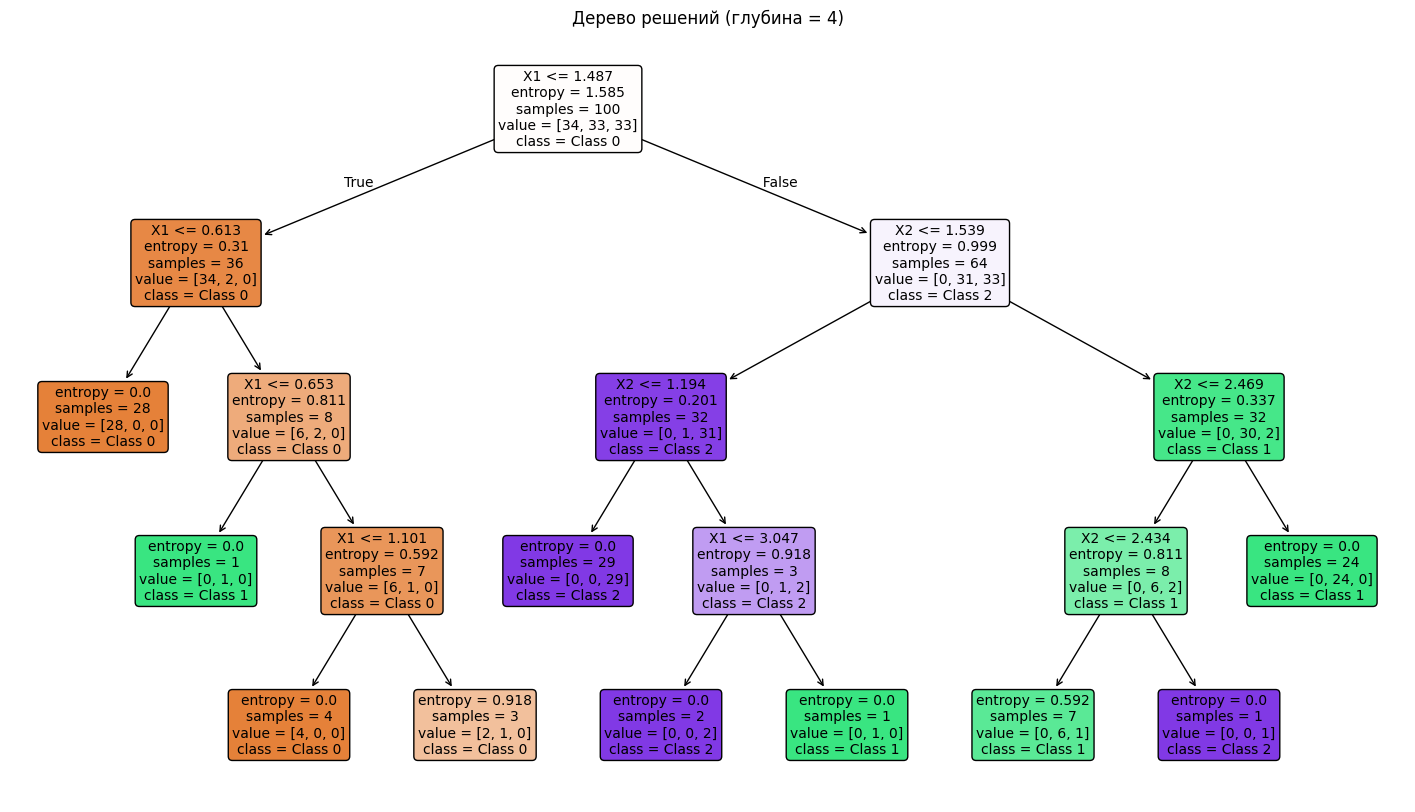

In [4]:
plt.figure(figsize=(18, 10))
plot_tree(clf_tree, feature_names=['X1', 'X2'], class_names=['Class 0', 'Class 1', 'Class 2'],
          filled=True, rounded=True, fontsize=10)
plt.title(f'Дерево решений (глубина = {depth})')
plt.show()

Каждый узел показывает: признак и порог разбиения, энтропию, число样本, распределение по классам. Цвет узла отражает преобладающий класс.

### Разделяющие области

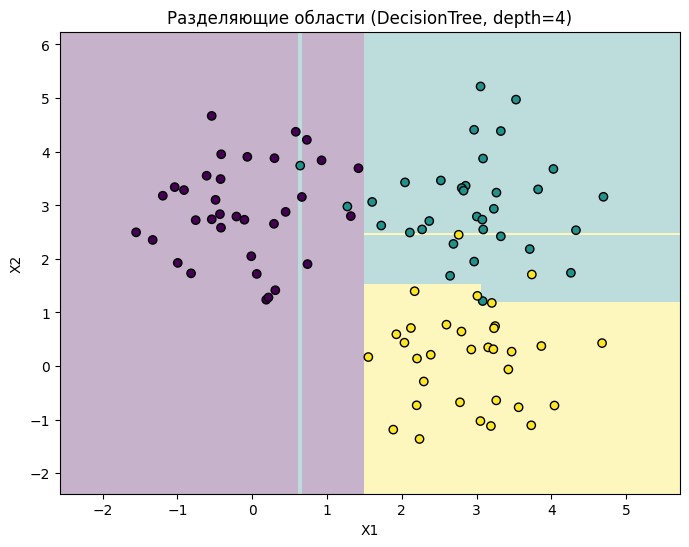

In [5]:
X0 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
X1 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)

plt.figure(figsize=(8, 6))
plt.pcolormesh(X0_grid, X1_grid, y_predict, cmap='viridis', alpha=0.3, shading='auto')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='black', linewidth=1)
plt.title(f'Разделяющие области (DecisionTree, depth={depth})')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Характерная для деревьев **прямоугольная** форма границ — каждое разбиение параллельно одной из осей.

### Оценка качества и предсказание для новой точки

In [6]:
y_pred = clf_tree.predict(X)
print('Матрица классификации:')
print(confusion_matrix(y, y_pred))
print(f'Accuracy = {accuracy_score(y, y_pred):.4f}')
print(f'F1_score (micro) = {f1_score(y, y_pred, average="micro"):.4f}')

observation_new = [[2, 1]]
pred_new = clf_tree.predict(observation_new)
print(f'\nПредсказание для точки {observation_new}: класс {pred_new[0]}')

Матрица классификации:
[[34  0  0]
 [ 1 32  0]
 [ 0  1 32]]
Accuracy = 0.9800
F1_score (micro) = 0.9800

Предсказание для точки [[2, 1]]: класс 2


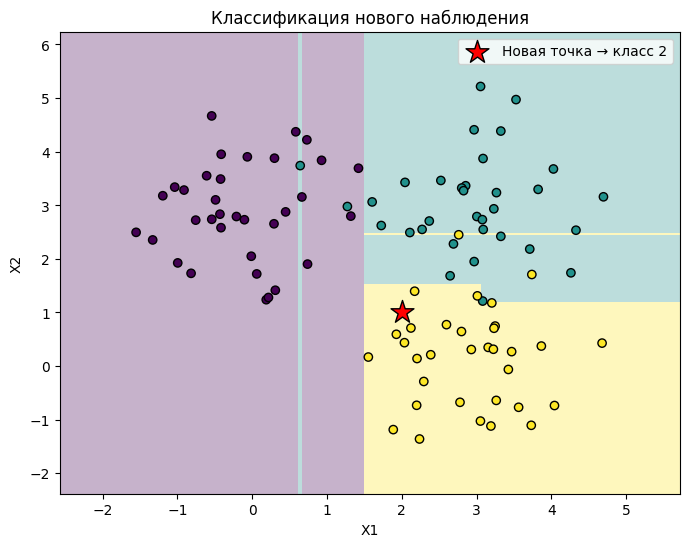

In [7]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(X0_grid, X1_grid, y_predict, cmap='viridis', alpha=0.3, shading='auto')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='black', linewidth=1)
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=300,
            c='red', edgecolors='k', label=f'Новая точка → класс {pred_new[0]}', zorder=5)
plt.title('Классификация нового наблюдения')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

## 3. Задача регрессии

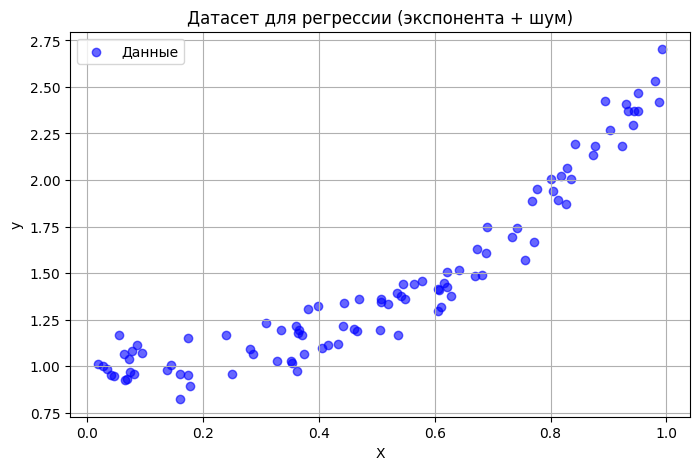

In [8]:
n_samples = 100
X_reg = np.sort(np.random.rand(n_samples)).reshape(-1, 1)
y_reg = np.exp(X_reg[:, 0] ** 2) + np.random.normal(0.0, 0.1, n_samples)

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, c='b', alpha=0.6, label='Данные')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Датасет для регрессии (экспонента + шум)')
plt.legend()
plt.grid(True)
plt.show()

### Обучение DecisionTreeRegressor

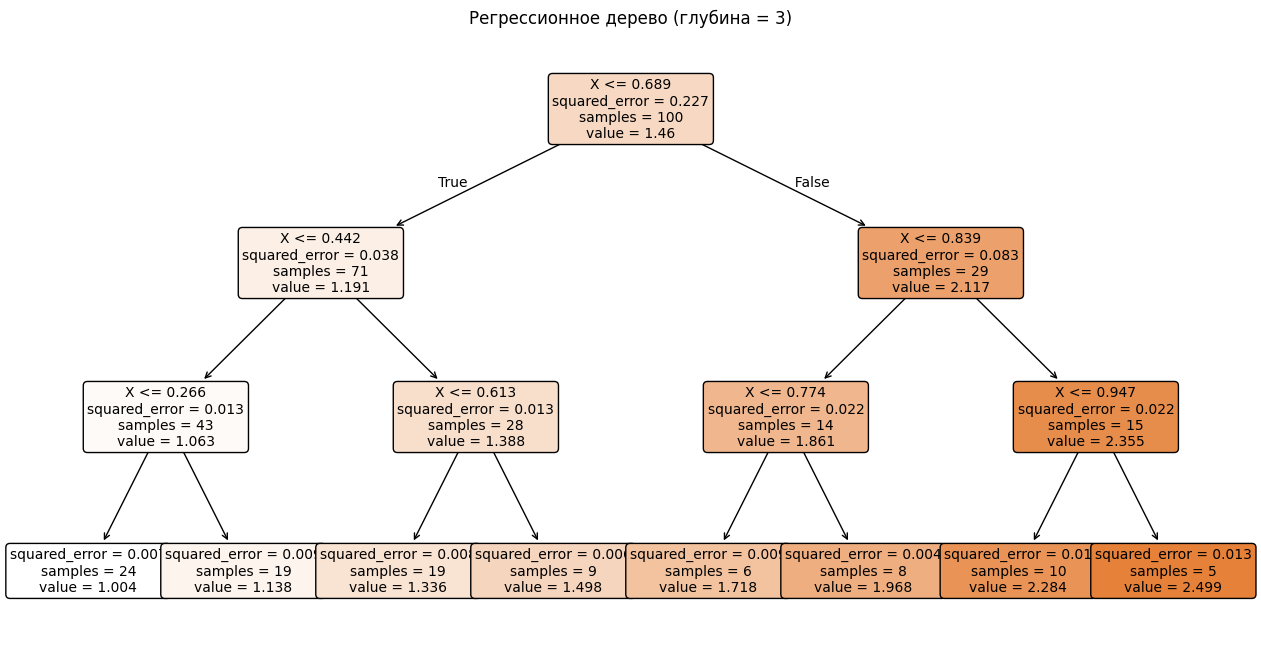

In [9]:
depth_reg = 3
reg_tree = DecisionTreeRegressor(max_depth=depth_reg, random_state=RANDOM_SEED)
reg_tree.fit(X_reg, y_reg)

y_pred_reg = reg_tree.predict(X_reg)

plt.figure(figsize=(16, 8))
plot_tree(reg_tree, feature_names=['X'], filled=True, rounded=True, fontsize=10)
plt.title(f'Регрессионное дерево (глубина = {depth_reg})')
plt.show()

### Кусочно-линейная регрессия

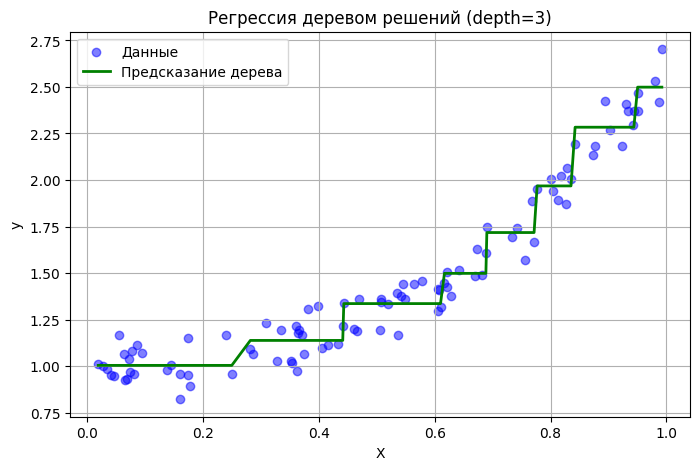

R² = 0.9647
MSE = 0.0080


In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, c='b', alpha=0.5, label='Данные')
plt.plot(X_reg, y_pred_reg, 'g', lw=2, label='Предсказание дерева')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Регрессия деревом решений (depth={depth_reg})')
plt.legend()
plt.grid(True)
plt.show()

print(f'R² = {r2_score(y_reg, y_pred_reg):.4f}')
print(f'MSE = {mean_squared_error(y_reg, y_pred_reg):.4f}')

### Предсказание для новой точки

Предсказание для x=0.7: y = 1.7177


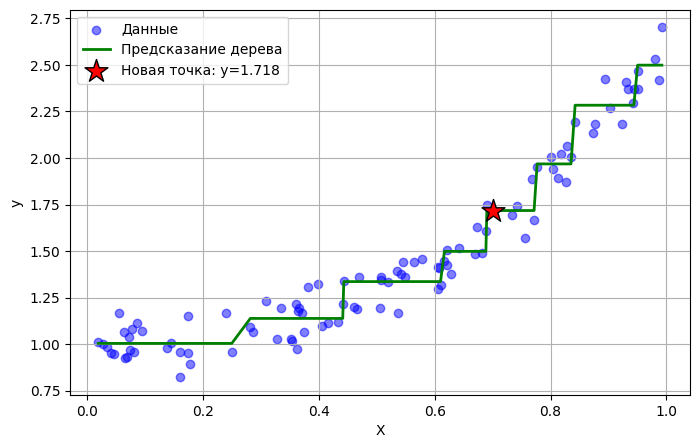

In [11]:
obs_new_reg = [[0.7]]
pred_reg = reg_tree.predict(obs_new_reg)
print(f'Предсказание для x={obs_new_reg[0][0]}: y = {pred_reg[0]:.4f}')

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, c='b', alpha=0.5, label='Данные')
plt.plot(X_reg, y_pred_reg, 'g', lw=2, label='Предсказание дерева')
plt.scatter(obs_new_reg[0][0], pred_reg[0], marker='*', s=300,
            c='red', edgecolors='k', label=f'Новая точка: y={pred_reg[0]:.3f}', zorder=5)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## Выводы

1. **Классификация**: DecisionTreeClassifier (entropy, depth=4) достигает accuracy ~0.99. Границы решений имеют характерную прямоугольную форму (оси-параллельные разбиения).
2. **Регрессия**: DecisionTreeRegressor (depth=3) даёт R² ≈ 0.96. Предсказания имеют кусочно-постоянный вид — типичный для деревьев.
3. Глубина дерева контролирует сложность модели: слишком большая — переобучение, слишком малая — недообучение.
4. Деревья не требуют нормализации данных и интерпретируемы (можно визуализировать всё дерево).